# Ejercicio 3: Inspección visual de un producto

Este ejercicio desarrolla un agente inteligente que inspecciona una imagen de 5×5 píxeles y decide qué hacer con el producto según la cantidad de píxeles defectuosos detectados.


### Ficha PEAS

| Elemento                    | Descripción                                                                                    |
| --------------------------- | ---------------------------------------------------------------------------------------------- |
| **P – Medida de desempeño** | Detectar correctamente los píxeles defectuosos y clasificar el producto de manera consistente. |
| **E – Entorno**             | Línea de producción, productos y cámara de inspección.                                         |
| **A – Acciones**            | Aprobar, enviar a revisión manual o rechazar el producto.                                      |
| **S – Percepción**          | Matriz de 5×5 de NumPy, donde 0 representa un píxel normal y 1 un píxel defectuoso.            |
| **Objetivo**                | Decidir qué hacer con el producto según la cantidad de píxeles defectuosos detectados.         |


### Justificación de las reglas

Un producto con 0 píxeles defectuosos se considera normal y puede aprobarse. Si presenta entre 1 y 3 defectos, se envía a revisión manual para verificar la gravedad de las anomalías. Si presenta más de 3 defectos, se rechaza debido a la cantidad de píxeles defectuosos detectados. Estas reglas permiten clasificar automáticamente los productos según el nivel de defectos observado.


In [1]:
import numpy as np

def agente_inspeccion(imagen):
    """
    Percepción (S): matriz 5x5 de NumPy
    0 = píxel normal
    1 = píxel defectuoso
    """

    imagen = np.asarray(imagen)

    defectos = int(np.sum(imagen))

    if defectos == 0:
        return "aprobar", "no se detectaron píxeles defectuosos"

    elif defectos <= 3:
        return "revisión manual", f"se detectaron {defectos} píxeles defectuosos"

    else:
        return "rechazar", f"se detectaron {defectos} píxeles defectuosos"

In [2]:
imagen_prueba = np.array([
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0],
    [0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0]
])

print(agente_inspeccion(imagen_prueba))

('revisión manual', 'se detectaron 3 píxeles defectuosos')


### Simulación y pruebas

Se realizan cinco pruebas con matrices de 5×5 que contienen diferentes cantidades de píxeles defectuosos. Se incluye un caso con 0 defectos y el caso límite de 3 defectos, que corresponde a la última cantidad que permite enviar el producto a revisión manual.


In [3]:
casos_inspeccion = [

    # Caso 1: 0 defectos
    np.array([
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]),

    # Caso 2: 1 defecto
    np.array([
        [1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]),

    # Caso 3: 3 defectos - CASO LÍMITE
    np.array([
        [1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]
    ]),

    # Caso 4: 4 defectos
    np.array([
        [1, 0, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]
    ]),

    # Caso 5: 6 defectos
    np.array([
        [1, 1, 0, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 1]
    ])
]

for numero, imagen in enumerate(casos_inspeccion, start=1):

    accion, motivo = agente_inspeccion(imagen)

    print(f"CASO {numero}")
    print(imagen)
    print("Cantidad de defectos:", int(np.sum(imagen)))
    print("Decisión:", accion)
    print("Motivo:", motivo)
    print("-" * 60)

CASO 1
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Cantidad de defectos: 0
Decisión: aprobar
Motivo: no se detectaron píxeles defectuosos
------------------------------------------------------------
CASO 2
[[1 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Cantidad de defectos: 1
Decisión: revisión manual
Motivo: se detectaron 1 píxeles defectuosos
------------------------------------------------------------
CASO 3
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
Cantidad de defectos: 3
Decisión: revisión manual
Motivo: se detectaron 3 píxeles defectuosos
------------------------------------------------------------
CASO 4
[[1 0 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 0]]
Cantidad de defectos: 4
Decisión: rechazar
Motivo: se detectaron 4 píxeles defectuosos
------------------------------------------------------------
CASO 5
[[1 1 0 0 0]
 [0 1 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]
Cantidad de defectos: 6
Decis

### Visualización opcional

Se visualizan las matrices de prueba para observar la ubicación de los píxeles defectuosos.


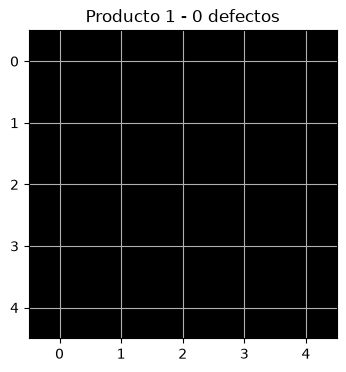

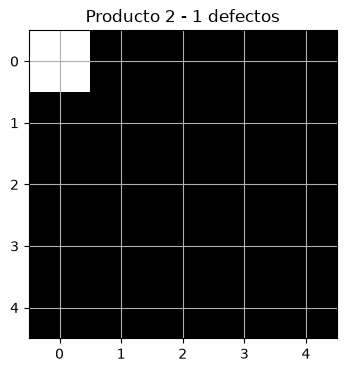

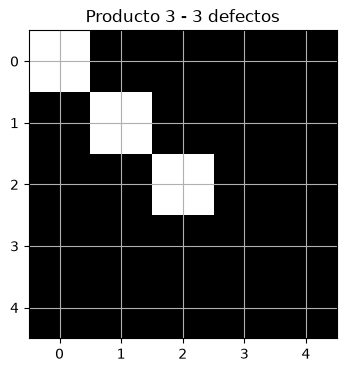

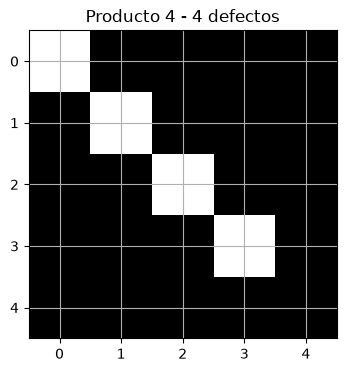

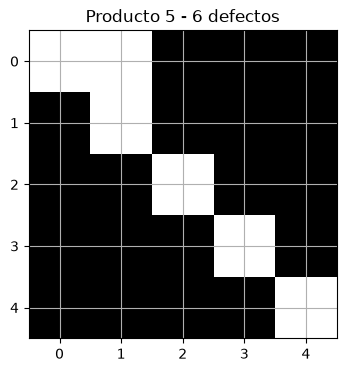

In [4]:
import matplotlib.pyplot as plt

for numero, imagen in enumerate(casos_inspeccion, start=1):

    plt.figure(figsize=(4, 4))

    plt.imshow(
        imagen,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    plt.title(
        f"Producto {numero} - {int(np.sum(imagen))} defectos"
    )

    plt.xticks(range(5))
    plt.yticks(range(5))

    plt.grid(True)

    plt.show()